In [1]:
import pandas as pd
import numpy as np
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob

import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shourya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shourya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
df1 = pd.read_csv(r"C:\Users\Shourya\Documents\amazon project\Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")
df2 = pd.read_csv(r"C:\Users\Shourya\Documents\amazon project\Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")
df1.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-10-09T00:00:00Z,True,177283626.0,3,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...


In [7]:
df2.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [8]:
df1.shape

(5000, 24)

In [9]:
df2.shape

(28332, 24)

In [10]:
df = pd.concat([df1, df2], ignore_index=True)

In [11]:
df.shape

(33332, 25)

In [12]:
import missingno as msno

In [13]:
# verifying schema consistency 
set(df1.columns) == set(df2.columns)

False

In [15]:
cols1 = set(df1.columns)
cols2 = set(df2.columns)

print("Only in df1:\n", cols1 - cols2)
print("\nOnly in df2:\n", cols2 - cols1)

Only in df1:
 {'reviews.dateAdded'}

Only in df2:
 {'reviews.didPurchase'}


In [16]:
common_cols = df1.columns.intersection(df2.columns)

df1 = df1[common_cols]
df2 = df2[common_cols]

In [18]:
set(df1.columns) == set(df2.columns)

True

In [19]:
df.duplicated(subset='reviews.text').sum()

np.int64(13660)

In [20]:
df = df.drop_duplicates(subset='reviews.text')

In [21]:
df.shape

(19672, 25)

In [22]:
df.isnull().sum().sort_values(ascending=False)

reviews.didPurchase    19663
reviews.id             19608
reviews.dateAdded      18759
reviews.doRecommend     9048
reviews.numHelpful      9019
reviews.title             11
reviews.username           3
sourceURLs                 0
reviews.text               0
reviews.sourceURLs         0
reviews.rating             0
reviews.dateSeen           0
id                         0
dateAdded                  0
manufacturerNumber         0
manufacturer               0
keys                       0
imageURLs                  0
primaryCategories          0
categories                 0
brand                      0
asins                      0
name                       0
dateUpdated                0
reviews.date               0
dtype: int64

In [23]:
df = df.drop(columns=[
    'reviews.didPurchase',
    'reviews.id',
    'reviews.dateAdded',
    'sourceURLs',
    'reviews.sourceURLs',
    'imageURLs',
    'keys'
])

In [24]:
df.shape

(19672, 18)

In [25]:
df['reviews.doRecommend'] = df['reviews.doRecommend'].fillna(False)

C:\Users\Shourya\AppData\Local\Temp\ipykernel_29584\193606028.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['reviews.doRecommend'] = df['reviews.doRecommend'].fillna(False)


In [26]:
df['reviews.numHelpful'] = df['reviews.numHelpful'].fillna(0)

In [27]:
df[['reviews.doRecommend','reviews.numHelpful']].isnull().sum()

reviews.doRecommend    0
reviews.numHelpful     0
dtype: int64

In [33]:
df['reviews.date'] = pd.to_datetime(df['reviews.date'], format='ISO8601', errors='coerce')

In [34]:
df['reviews.date'].isnull().sum()

np.int64(0)

In [35]:
df['reviews.text'].str.len().describe()

count    19672.000000
mean       142.364681
std        188.772084
min          1.000000
25%         55.750000
50%         90.000000
75%        167.000000
max       8351.000000
Name: reviews.text, dtype: float64

In [36]:
df = df[df['reviews.text'].str.len() >= 20]

In [37]:
df.shape

(18629, 18)

In [38]:
df['reviews.rating'].value_counts().sort_index()

reviews.rating
1      724
2      457
3      820
4     3547
5    13081
Name: count, dtype: int64

In [39]:
df['rating_sentiment'] = df['reviews.rating'].apply(
    lambda x: 'negative' if x <= 2 else ('neutral' if x == 3 else 'positive')
)

In [40]:
df['rating_sentiment'].value_counts()

rating_sentiment
positive    16628
negative     1181
neutral       820
Name: count, dtype: int64

In [41]:
df.groupby('reviews.rating')['reviews.text'].apply(lambda x: x.str.len().mean())

reviews.rating
1    215.067680
2    222.783370
3    175.986585
4    168.180434
5    136.778457
Name: reviews.text, dtype: float64

In [42]:
df['reviews.text'].apply(type).value_counts()

reviews.text
<class 'str'>    18629
Name: count, dtype: int64

In [43]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# keep negations to preserve sentiment meaning
negations = {"no", "nor", "not", "don't", "didn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't", "won't"}

stop_words = stop_words - negations

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)   # keep apostrophes for negations
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [45]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shourya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shourya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [46]:
df['clean_review'] = df['reviews.text'].apply(clean_text)

In [47]:
df['clean_review'] = df['reviews.text'].apply(clean_text)

In [48]:
df[['reviews.text','clean_review']].head()

,reviews.text,clean_review
0,I thought it would be as big as small paper bu...,thought would big small paper turn like palm t...
1,This kindle is light and easy to use especiall...,kindle light easy use especially beach
2,Didnt know how much i'd use a kindle so went f...,didnt know much 'd use kindle went lower end i...
3,I am 100 happy with my purchase. I caught it o...,happy purchase caught sale really good price n...
4,Solid entry level Kindle. Great for kids. Gift...,solid entry level kindle great kids gifted kid...


In [51]:
df['clean_review'].str.contains('not').sum()

np.int64(3047)

In [52]:
df[['reviews.text','clean_review']].sample(5, random_state=1)

,reviews.text,clean_review
8794,works good so far. just started using them.,works good far started using
20222,My two daughters really enjoy using their Fire...,two daughters really enjoy using fire tablet r...
19877,I got this for ky 3 year old and she loves it....,got ky year old loves dropped fews times outsi...
205,I like the ease and usage of the amazon show. ...,like ease usage amazon show amazon echo decide...
12026,"Great Bargain, were shipped on time and the pa...",great bargain shipped time packing good no dam...


In [53]:
import re

def expand_contractions(text):
    text = re.sub(r"didnt", "did not", text)
    text = re.sub(r"doesnt", "does not", text)
    text = re.sub(r"dont", "do not", text)
    text = re.sub(r"cant", "can not", text)
    text = re.sub(r"couldnt", "could not", text)
    text = re.sub(r"wouldnt", "would not", text)
    text = re.sub(r"shouldnt", "should not", text)
    text = re.sub(r"isnt", "is not", text)
    text = re.sub(r"wasnt", "was not", text)
    text = re.sub(r"werent", "were not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"n't", " not", text)
    return text

df['clean_review'] = df['clean_review'].apply(expand_contractions)

In [54]:
df[['clean_review']].head()

,clean_review
0,thought would big small paper turn like palm t...
1,kindle light easy use especially beach
2,did not know much 'd use kindle went lower end...
3,happy purchase caught sale really good price n...
4,solid entry level kindle great kids gifted kid...


In [55]:
from textblob import TextBlob

df['polarity'] = df['clean_review'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [56]:
df['polarity'].describe()

count    18629.000000
mean         0.335183
std          0.289626
min         -1.000000
25%          0.125000
50%          0.333333
75%          0.520833
max          1.000000
Name: polarity, dtype: float64

In [57]:
def classify_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df['text_sentiment'] = df['polarity'].apply(classify_sentiment)

In [58]:
df['text_sentiment'].value_counts()

text_sentiment
positive    15415
neutral      1624
negative     1590
Name: count, dtype: int64

In [59]:
df['sentiment_mismatch'] = df['text_sentiment'] != df['rating_sentiment']

In [60]:
df['sentiment_mismatch'].mean()

np.float64(0.191153577755113)

In [61]:
pd.crosstab(df['rating_sentiment'], df['text_sentiment'])

text_sentiment,negative,neutral,positive
rating_sentiment,,,
negative,559,171,451
neutral,189,88,543
positive,842,1365,14421


In [62]:
hidden_issues = df[
    (df['rating_sentiment'] == 'positive') &
    (df['text_sentiment'] == 'negative')
]

len(hidden_issues)

842

In [63]:
def sentiment_strength(score):
    if score >= 0.6:
        return 'strongly_positive'
    elif score >= 0.2:
        return 'positive'
    elif score > -0.2:
        return 'neutral'
    elif score > -0.6:
        return 'negative'
    else:
        return 'strongly_negative'

df['sentiment_strength'] = df['polarity'].apply(sentiment_strength)

In [64]:
df['sentiment_strength'].value_counts()

sentiment_strength
positive             8884
neutral              5500
strongly_positive    3783
negative              416
strongly_negative      46
Name: count, dtype: int64

In [65]:
from collections import Counter

negative_reviews = df[df['text_sentiment'] == 'negative']['clean_review']

all_words = " ".join(negative_reviews).split()

common_negative_words = Counter(all_words).most_common(20)

common_negative_words

[('not', 1190),
 ('batteries', 1084),
 ('long', 454),
 ('last', 442),
 ('amazon', 325),
 ('battery', 222),
 ('use', 206),
 ("'s", 201),
 ('work', 198),
 ('like', 184),
 ('buy', 182),
 ('brand', 175),
 ('well', 173),
 ('would', 170),
 ('bought', 161),
 ('tablet', 159),
 ('time', 152),
 ('one', 149),
 ('name', 147),
 ('used', 145)]

In [66]:
noise_words = {
    'not','would','one','like','use','used','buy','bought',
    'well','work','time','amazon','brand','name','s',"'s"
}

filtered_words = [
    word for word in all_words
    if word not in noise_words and len(word) > 2
]

from collections import Counter
Counter(filtered_words).most_common(15)

[('batteries', 1084),
 ('long', 454),
 ('last', 442),
 ('battery', 222),
 ('tablet', 159),
 ('get', 142),
 ('price', 136),
 ('expensive', 125),
 ('less', 115),
 ('duracell', 108),
 ('brands', 103),
 ('remote', 103),
 ('bad', 101),
 ('little', 100),
 ('dead', 95)]

In [67]:
hidden_reviews = " ".join(hidden_issues['clean_review']).split()

from collections import Counter
Counter(hidden_reviews).most_common(15)

[('not', 446),
 ('batteries', 442),
 ('long', 261),
 ('last', 179),
 ('well', 132),
 ('amazon', 127),
 ('tablet', 120),
 ('work', 115),
 ('expensive', 113),
 ('like', 108),
 ("'s", 105),
 ('price', 105),
 ('name', 96),
 ('use', 95),
 ('brand', 87)]

In [68]:
noise_words = {
    'not','well','like','work','use','amazon',
    'name','brand','s',"'s"
}

filtered_hidden = [
    word for word in hidden_reviews
    if word not in noise_words and len(word) > 2
]

from collections import Counter
Counter(filtered_hidden).most_common(15)

[('batteries', 442),
 ('long', 261),
 ('last', 179),
 ('tablet', 120),
 ('expensive', 113),
 ('price', 105),
 ('battery', 84),
 ('time', 77),
 ('brands', 77),
 ('bought', 75),
 ('one', 75),
 ('buy', 75),
 ('get', 73),
 ('would', 71),
 ('little', 66)]

In [69]:
df['review_length'] = df['reviews.text'].str.len()
df['word_count'] = df['reviews.text'].str.split().apply(len)

In [70]:
df[['review_length','word_count']].describe()

,review_length,word_count
count,18629.000000,18629.000000
mean,149.635783,28.150411
std,191.394631,35.551914
min,20.000000,1.000000
25%,60.000000,11.000000
50%,95.000000,18.000000
75%,174.000000,33.000000
max,8351.000000,1539.000000


In [71]:
def helpful_bucket(votes):
    if votes == 0:
        return 'none'
    elif votes <= 2:
        return 'low'
    elif votes <= 10:
        return 'medium'
    else:
        return 'high'

df['helpfulness_level'] = df['reviews.numHelpful'].apply(helpful_bucket)

In [72]:
df['helpfulness_level'].value_counts()

helpfulness_level
none      17790
low         558
medium      204
high         77
Name: count, dtype: int64

In [73]:
df['recommendation_alignment'] = (
    (df['reviews.doRecommend'] == True) & (df['text_sentiment'] == 'positive')
)

In [74]:
df['recommendation_alignment'].value_counts()

recommendation_alignment
False    9509
True     9120
Name: count, dtype: int64

In [75]:
true_detractors = df[
    (df['text_sentiment'] == 'negative') &
    (df['reviews.doRecommend'] == False)
]

len(true_detractors)

1243

In [76]:
def satisfaction_segment(row):
    if row['text_sentiment'] == 'positive' and row['reviews.doRecommend']:
        return 'promoter'
    elif row['text_sentiment'] == 'negative' and not row['reviews.doRecommend']:
        return 'detractor'
    else:
        return 'passive'

df['satisfaction_segment'] = df.apply(satisfaction_segment, axis=1)

In [77]:
df['satisfaction_segment'].value_counts()

satisfaction_segment
promoter     9120
passive      8266
detractor    1243
Name: count, dtype: int64

In [78]:
df['primary_category'] = df['categories'].str.split(',').str[0].str.strip()
df['primary_category'].value_counts().head(10)

primary_category
AA                                7843
Fire Tablets                      5744
Computers                         1334
Amazon Echo                       1326
Electronics                        789
eBook Readers                      745
Computers/Tablets & Networking     275
Office                             235
Tablets                             87
Computers & Accessories             57
Name: count, dtype: int64

In [79]:
def normalize_category(cat):
    if 'AA' in cat or 'Battery' in cat:
        return 'Batteries'
    elif 'Fire' in cat or 'Tablet' in cat:
        return 'Tablets'
    elif 'Echo' in cat:
        return 'Smart Home'
    elif 'eBook' in cat or 'Reader' in cat:
        return 'eReaders'
    elif 'Computer' in cat:
        return 'Computing'
    elif 'Electronics' in cat:
        return 'Electronics'
    else:
        return 'Other'

df['category_group'] = df['primary_category'].apply(normalize_category)

In [80]:
df['category_group'].value_counts()

category_group
Batteries      7843
Tablets        6131
Computing      1425
Smart Home     1326
Electronics     808
eReaders        775
Other           321
Name: count, dtype: int64

In [81]:
pd.crosstab(df['category_group'], df['text_sentiment'], normalize='index')

text_sentiment,negative,neutral,positive
category_group,,,
Batteries,0.138850,0.112584,0.748566
Computing,0.049123,0.065965,0.884912
Electronics,0.042079,0.060644,0.897277
Other,0.059190,0.049844,0.890966
Smart Home,0.038462,0.067119,0.894419
Tablets,0.047790,0.075029,0.877182
eReaders,0.043871,0.042581,0.913548


In [83]:
df.to_csv("processed_reviews_final.csv", index=False)

In [84]:
import os
os.listdir()

['.ipynb_checkpoints',
 '1429_1.csv',
 'Amazon_customer_sentiment_analysis.ipynb',
 'Amazon_customer_sentiment_analysis2.ipynb',
 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv',
 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv',
 'processed_reviews_final.csv']

In [2]:
pd.crosstab(df['category_group'], df['satisfaction_segment'], normalize='index')

NameError: name 'pd' is not defined

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("processed_reviews_final.csv")

In [6]:
pd.crosstab(df['category_group'],
            df['satisfaction_segment'],
            normalize='index')

satisfaction_segment,detractor,passive,promoter
category_group,,,
Batteries,0.138850,0.861150,0.000000
Computing,0.026667,0.139649,0.833684
Electronics,0.011139,0.146040,0.842822
Other,0.034268,0.264798,0.700935
Smart Home,0.012066,0.138009,0.849925
Tablets,0.012233,0.137661,0.850106
eReaders,0.006452,0.107097,0.886452


In [7]:
cat_perf = pd.crosstab(
    df['category_group'],
    df['satisfaction_segment'],
    normalize='index'
)

cat_perf = cat_perf[['promoter', 'detractor']]
cat_perf

satisfaction_segment,promoter,detractor
category_group,,
Batteries,0.000000,0.138850
Computing,0.833684,0.026667
Electronics,0.842822,0.011139
Other,0.700935,0.034268
Smart Home,0.849925,0.012066
Tablets,0.850106,0.012233
eReaders,0.886452,0.006452


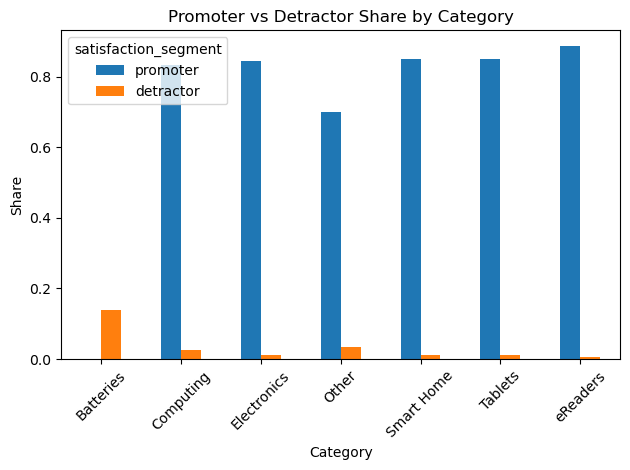

In [8]:
import matplotlib.pyplot as plt

cat_perf.plot(kind='bar')

plt.title('Promoter vs Detractor Share by Category')
plt.xlabel('Category')
plt.ylabel('Share')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [9]:
neg_sent = pd.crosstab(
    df['category_group'],
    df['text_sentiment'],
    normalize='index'
)

neg_sent = neg_sent['negative'].sort_values(ascending=False)
neg_sent

category_group
Batteries      0.138850
Other          0.059190
Computing      0.049123
Tablets        0.047790
eReaders       0.043871
Electronics    0.042079
Smart Home     0.038462
Name: negative, dtype: float64

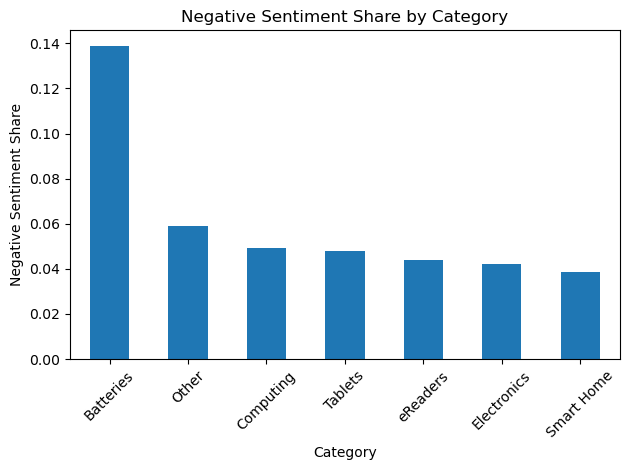

In [10]:
neg_sent.plot(kind='bar')

plt.title('Negative Sentiment Share by Category')
plt.xlabel('Category')
plt.ylabel('Negative Sentiment Share')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
df.to_csv("processed_reviews_final.csv", index=False)

In [12]:
import os
os.listdir()

['.ipynb_checkpoints',
 '1429_1.csv',
 'Amazon_customer_sentiment_analysis.ipynb',
 'Amazon_customer_sentiment_analysis2.ipynb',
 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv',
 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv',
 'processed_reviews_final.csv']

In [15]:
df.shape
df.columns
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,manufacturer,manufacturerNumber,...,text_sentiment,sentiment_mismatch,sentiment_strength,review_length,word_count,helpfulness_level,recommendation_alignment,satisfaction_segment,primary_category,category_group
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,Amazon,B00ZV9PXP2,...,negative,True,neutral,211,41,none,False,detractor,Computers,Computing
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,Amazon,B00ZV9PXP2,...,positive,False,positive,63,12,none,True,promoter,Computers,Computing
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,Amazon,B00ZV9PXP2,...,positive,False,neutral,107,24,none,True,promoter,Computers,Computing
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,Amazon,B00ZV9PXP2,...,positive,False,positive,757,148,medium,True,promoter,Computers,Computing
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,Amazon,B00ZV9PXP2,...,positive,False,positive,176,36,none,True,promoter,Computers,Computing


In [16]:
df_sql = df.rename(columns={
    'name': 'product',
    'reviews.text': 'review_text',
    'reviews.title': 'review_title',
    'reviews.rating': 'rating',
    'reviews.date': 'review_date',
    'reviews.numHelpful': 'helpful_votes',
    'reviews.doRecommend': 'recommend'
})

df_sql = df_sql[[
    'product',
    'brand',
    'category_group',
    'primary_category',
    'review_text',
    'review_title',
    'rating',
    'review_date',
    'helpful_votes',
    'recommend',
    'clean_review',
    'polarity',
    'text_sentiment',
    'sentiment_strength',
    'sentiment_mismatch',
    'rating_sentiment',
    'satisfaction_segment',
    'recommendation_alignment',
    'helpfulness_level',
    'review_length',
    'word_count'
]]

df_sql.to_csv("reviews_postgres.csv", index=False)

In [17]:
df_sql['helpful_votes'] = df_sql['helpful_votes'].fillna(0).astype(int)

In [18]:
df_sql['helpful_votes'].head()

0    0
1    0
2    0
3    3
4    0
Name: helpful_votes, dtype: int64

In [19]:
df_sql.to_csv("reviews_postgres.csv", index=False)